In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il
import pickle
from scipy.optimize import curve_fit
import scipy

In [669]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_sum = pickle.load(f)
    Pk_sum = pickle.load(f)
print("shotnoise", Pk_sum.attrs["shotnoise"])

shotnoise 304.0903879154701


In [49]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM11-11.5.pickle", "rb") as f:
    Pk_mean11 = pickle.load(f)
    Pk11 = pickle.load(f)
print("shotnoise", Pk11.attrs["shotnoise"])

shotnoise 105.90268152292435


In [50]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM12-12.5.pickle", "rb") as f:
    Pk_mean12 = pickle.load(f)
    Pk12 = pickle.load(f)
print("shotnoise", Pk12.attrs["shotnoise"])

shotnoise 926.3583221039135


In [51]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM13-13.5.pickle", "rb") as f:
    Pk_mean13 = pickle.load(f)
    Pk13 = pickle.load(f)
print("shotnoise", Pk13.attrs["shotnoise"])

shotnoise 18362.083969661016


In [52]:
from nbodykit.lab import cosmology as n_cosmology
#c      = n_cosmology.Planck15
#n_cosmology.P_k_max=100
c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [53]:
def kernel_NL(ks, R=1, nbins=100):
    results = []
    r = np.linspace(0, R, nbins)
    xi = cf_nl(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [54]:
def kernel_lin(ks, R=1, nbins=100):
    results = []
    r = np.linspace(0, R, nbins)
    xi = cf_lin(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [56]:
def W_R(k, R=1):
    return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3

In [302]:
def scale_dependent_bias(logk, a, b, c, d, logk0):
    bias_k = a + b*(logk-logk0) + c*(logk-logk0)**2 + d*(logk-logk0)**3
    return bias_k

In [342]:
def fit_pow(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1, kernel_type="lin"):
    bias_k = scale_dependent_bias(logk, a, b, c, d, logk0)

    #mask = logk < logk0
    #result[mask] = a
    if kernel_type == "lin":
        kernel = kernel_lin(10**logk, R=R)
    elif kernel_type == "new":
        kernel = kernel_new(10**logk, R=R)
    
    result1 = bias_k*Plin(10**logk) - bias_k*kernel - ((4*np.pi*R**3)/3)*W_R(10**logk, R)
    
    return result1

In [357]:
def fit_pow_lin(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1):
    return fit_pow(logk, a, b, c, d, logk0, R, kernel_type="lin")

In [356]:
def fit_pow_new(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1):
    return fit_pow(logk, a, b, c, d, logk0, R, kernel_type="new")

In [308]:

logks = np.arange(-1.5, 1.5, 0.1)
bias = scale_dependent_bias(logks, *pop_fit12[:-1])
new_pk_lin = bias*Plin(10**logks)

In [320]:
with open("new_pk_lin.txt", "w") as f:
    for i, logk in enumerate(logks):
        print(logk, new_pk_lin[i], file=f)

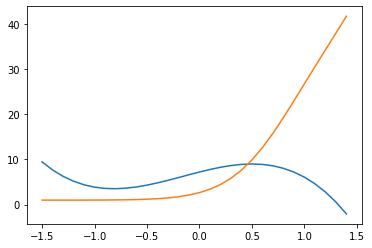

In [314]:
plt.plot(logks, bias)
plt.plot(logks, Pnl(10**logks)/Plin(10**logks))

In [336]:
from colossus.cosmology import cosmology as colossus_cosmology
cosmo_colossus = colossus_cosmology.setCosmology(cosmo_name="planck15")
new_pk_colossus = cosmo_colossus.matterPowerSpectrum(k=10**logks,z=1.5, path="new_pk_lin.txt")
r_arr = np.arange(0.01, 1, 0.01)
cf_new = cosmo_colossus.correlationFunction(r_arr, z=1.5)

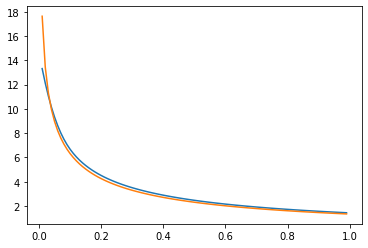

In [340]:
plt.plot(r_arr, cf_lin(r_arr))
plt.plot(r_arr, cf_new)

In [351]:
def kernel_new(ks, R=1, nbins=100):
    
    cosmo_colossus = colossus_cosmology.setCosmology(cosmo_name="planck15")
    new_pk_colossus = cosmo_colossus.matterPowerSpectrum(k=10**logks,z=1.5, path="new_pk_lin.txt")
    
    results = []
    r = np.linspace(1e-3, R, nbins)
    cf_new = cosmo_colossus.correlationFunction(r, z=1.5)
    xi = cf_new
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [158]:
def fit_pNL(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, bias=3, R=1):
    result = a + b*(logk-logk0) + c*(logk-logk0)**2 + d*(logk-logk0)**3
    mask = logk < logk0
    result[mask] = a
    return result

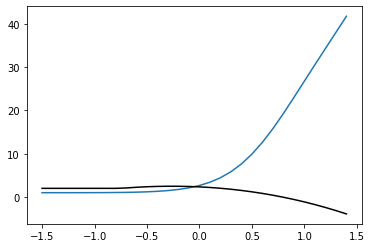

In [160]:
plt.plot(logks, Pnl(10**logks)/Plin(10**logks))
plt.plot(logks, fit_pNL(logks, *pop_fit12), c="k")

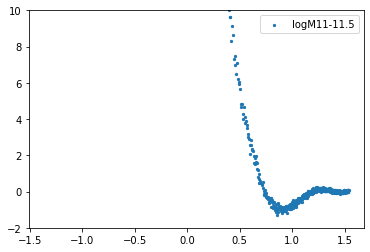

In [45]:
plt.scatter(np.log10(Pk11["k"]),Pk11["power"].real-Pk11.attrs["shotnoise"], s=5, label="logM11-11.5")
plt.ylim(-2,10)
plt.legend()

In [ ]:
mask = (np.log10(Pk12["k"]) > -0.5) & ((np.log10(Pk12["k"]) < 1.5))
logk12 = np.log10(Pk12["k"])[mask]
pow12 = (Pk12["power"].real-Pk12.attrs["shotnoise"])[mask]

mask = (np.log10(Pk11["k"]) > -0.5) & ((np.log10(Pk11["k"]) < 1.5))
logk11 = np.log10(Pk11["k"])[mask]
pow11 = (Pk11["power"].real-Pk11.attrs["shotnoise"])[mask]

In [ ]:
p0_12 = [1,1,0.01,0.1,-0.5,2.44,1]
bounds12=([-2, -2, -2,-2, -0.9, 2.43, 0], [2, 2, 2,5, -0.4, 2.45, 1])
pop_fit12, pcov12 = curve_fit(fit_pow, logk12,pow12,maxfev = 4000,p0=p0, bounds=bounds)

(0.0, 10.0)

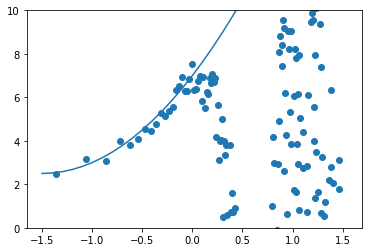

In [232]:
plt.scatter(np.log10(Pk12["k"]),(Pk12["power"].real-Pk12.attrs["shotnoise"])/Plin(Pk12["k"]), label="logM12-12.5")
logks = np.arange(-1.5, 1.5, 0.1)
plt.plot(logks, 2*(logks+1.5)**2 + 2.5)
plt.ylim(0,10)

(0.0, 10.0)

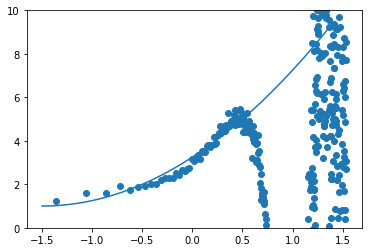

In [668]:
plt.scatter(np.log10(Pk11["k"]),(Pk11["power"].real-Pk11.attrs["shotnoise"])/Plin(Pk11["k"]), label="logM12-12.5")
logks = np.arange(-1.5, 1.5, 0.1)
plt.plot(logks, 1*(logks+1.5)**2 + 1)
plt.ylim(0,10)

(0.0, 10.0)

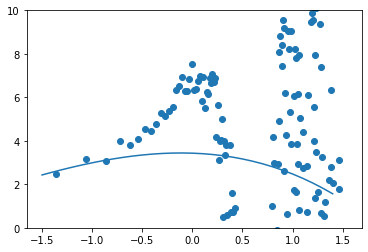

In [636]:
b = scale_dependent_bias(logks, *pop_fit12[:-1])
plt.scatter(np.log10(Pk12["k"]),(Pk12["power"].real-Pk12.attrs["shotnoise"])/Plin(Pk12["k"]), label="logM12-12.5")

plt.plot(logks, b)
plt.ylim(0,10)

(0.0, 10.0)

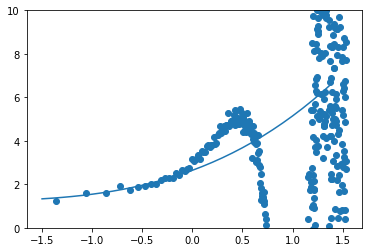

In [635]:
b = scale_dependent_bias(logks, *pop_fit11[:-1])
plt.scatter(np.log10(Pk11["k"]),(Pk11["power"].real-Pk11.attrs["shotnoise"])/Plin(Pk11["k"]), label="logM12-12.5")

plt.plot(logks, b)
plt.ylim(0,10)

(-50.0, 100.0)

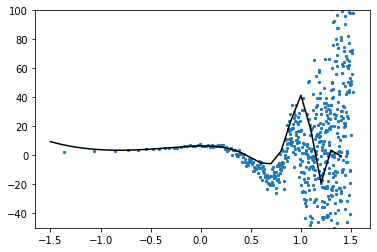

In [317]:
plt.scatter(np.log10(Pk12["k"]),(Pk12["power"].real-Pk12.attrs["shotnoise"])/Plin(Pk12["k"]), label="logM12-12.5",s=5)
y = fit_pow(logk = logks, a = 2.5, b=0, c=3, d=0, logk0=-1.4, R=0.6)/Plin(10**logks)
plt.plot(logks, fit_pow(logks, *pop_fit12)/Plin(10**logks), label="corrected pk", c="k")
#plt.plot(logks, y)
plt.ylim(-50,100)

(-10.0, 10.0)

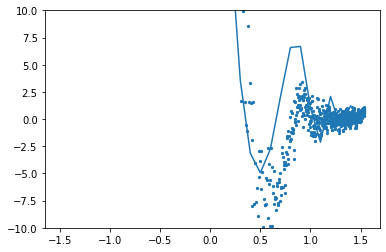

In [319]:
plt.scatter(np.log10(Pk12["k"]),(Pk12["power"].real-Pk12.attrs["shotnoise"]), label="logM12-12.5",s=5)
y = fit_pow(logk = logks, a = 2.5, b=0, c=1, logk0=-1.5,R=0.7)

plt.plot(logks, y)
plt.ylim(-10,10)

In [670]:
def optimise_fit(Pk, logM=12, logk_scale=-0.5):
    #mask = (np.log10(Pk["k"]) > logk_scale) 
    mask = (np.log10(Pk["k"]) > -1.5) & (np.log10(Pk["k"]) < 1.5)
    logk1 = np.log10(Pk["k"])[mask]
    pow1 = (Pk["power"].real-Pk.attrs["shotnoise"])[mask]
    a1 = 2.5
    b1 = 0
    c1 = 0
    d1 = 0
    logk0 = -1.5
    if logM == 12:
        bias1 = 1
        R1 = 0.7
        Rmin = 0.5
        Rmax = 1
        bias_min = 0.9
        bias_max = 1.1
    elif logM == 11:
        R1 = 0.3
        Rmin = 0.1
        Rmax = 0.6
    
    
    #weighting_mask = (np.log10(Pk["k"][mask]) > 0.7) & (np.log10(Pk["k"][mask]) < 1.3)
    #weighting = np.ones(len(Pk["k"][mask]))
    #weighting = np.where(weighting_mask,  weighting, 100)
    weighting = Pk["power"].real[mask]
    #p0_1 = [a1, b1, c1, d1,logk0,bias1,R1]
    #bounds1=([-2, -2, -2,-2, -2, bias_min, Rmin], [4, 4, 4,2, 1, bias_max,Rmax])
    p0_1 = [a1, b1, c1, d1,logk0,R1]
    bounds1=([-2, -0.1, -0.1,-0.1, -2, Rmin], [6, 0.1, 0.1,0.1, 1, Rmax])
    pop_fit1, pcov1 = curve_fit(fit_pow_lin, logk1,pow1,maxfev = 4000,p0=p0_1, bounds=bounds1, sigma=weighting, absolute_sigma=True)

    return pop_fit1

In [671]:
pop_fit12 = optimise_fit(Pk_sum)
print(pop_fit12)

[ 3.36387309  0.1         0.1         0.1        -2.          0.5       ]


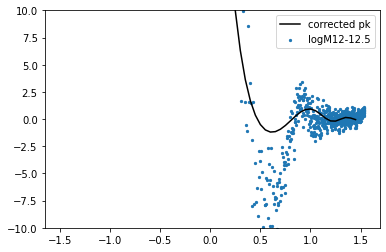

In [642]:

logks = np.arange(-1.5,1.5, 0.05)
plt.scatter(np.log10(Pk12["k"]),Pk12["power"].real-Pk12.attrs["shotnoise"], s=5, label="logM12-12.5")
plt.plot(logks, fit_pow_lin(logks, *pop_fit12), label="corrected pk", c="k")

plt.ylim(-10,10)
plt.legend()

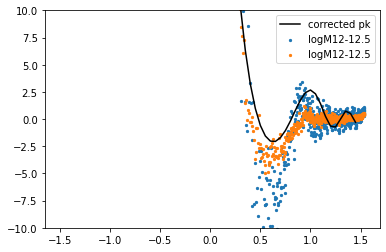

In [673]:

logks = np.arange(-1.5,1.5, 0.05)
plt.scatter(np.log10(Pk12["k"]),Pk12["power"].real-Pk12.attrs["shotnoise"], s=5, label="logM12-12.5")

plt.scatter(np.log10(Pk12["k"]),Pk_sum["power"].real-Pk_sum.attrs["shotnoise"], s=5, label="logM12-12.5")
plt.plot(logks, fit_pow_lin(logks, *pop_fit12), label="corrected pk", c="k")

plt.ylim(-10,10)
plt.legend()

In [622]:
pop_fit11 = optimise_fit(Pk11, logM=11)
print(pop_fit11)

[ 1.24466086  0.1         0.1         0.1        -2.          0.12764503]


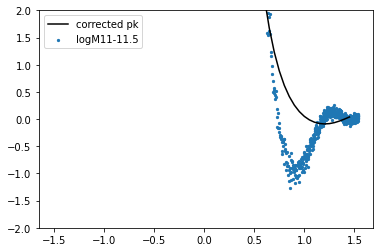

In [625]:

logks = np.arange(-1.5,1.5, 0.05)
plt.scatter(np.log10(Pk11["k"]),Pk11["power"].real-Pk11.attrs["shotnoise"], s=5, label="logM11-11.5")
#plt.plot(logks, fit_pow_lin(logks, *pop_fit11), label="corrected pk", c="k")

plt.ylim(-2,2)
plt.legend()

In [383]:
def optimise_fit_new(Pk, logM=12, logk_scale=-0.5):
    mask = (np.log10(Pk["k"]) > logk_scale) & (np.log10(Pk["k"]) < 1.5)
    logk1 = np.log10(Pk["k"])[mask]
    pow1 = (Pk["power"].real-Pk.attrs["shotnoise"])[mask]
    a1 = 2.5
    b1 = 0
    c1 = 3
    d1 = 0
    logk0 = -1.5
    if logM == 12:
        bias1 = 1
        R1 = 0.7
        Rmin = 0.5
        Rmax = 1.5
        bias_min = 0.9
        bias_max = 1.1
        
    weighting_mask = (np.log10(Pk["k"][mask]) > 0) & (np.log10(Pk["k"][mask]) < 1)
    weighting = np.ones(len(Pk["k"][mask]))
    np.where(weighting_mask, weighting, 10)
                        
        
    #p0_1 = [a1, b1, c1, d1,logk0,bias1,R1]
    #bounds1=([-2, -2, -2,-2, -2, bias_min, Rmin], [4, 4, 4,2, 1, bias_max,Rmax])
    p0_1 = [a1, b1, c1, d1,logk0,R1]
    bounds1=([-2, -2, -2,-5, -2, Rmin], [6, 4, 6,2, 1, Rmax])
    pop_fit1, pcov1 = curve_fit(fit_pow_new, logk1,pow1,maxfev = 4000,p0=p0_1, bounds=bounds1, sigma=weighting)
    return pop_fit1

In [384]:
pop_fit12_new = optimise_fit_new(Pk12)
print(pop_fit12_new)

[ 4.43597765  4.          6.         -5.         -0.4834621   0.54190707]


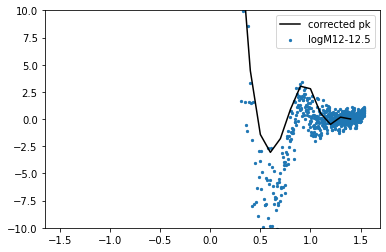

In [638]:

logks = np.arange(-1.5,1.5, 0.1)
plt.scatter(np.log10(Pk12["k"]),Pk12["power"].real-Pk12.attrs["shotnoise"], s=5, label="logM12-12.5")
plt.plot(logks, fit_pow_new(logks, *pop_fit12_new), label="corrected pk", c="k")

plt.ylim(-10,10)
plt.legend()

In [141]:
def fit_pow2(logk, a=1,logk0=0, bias=3, R=1):
    #result = a + b*(logk-logk0) + c*(logk-logk0)**2 + d*(logk-logk0)**3
    result = np.exp((logk-logk0)/a)
    
    result = result*bias*Plin(10**logk) - bias*kernel_NL(10**logk, R=R) - ((4*np.pi*R**3)/3)*W_R(10**logk, R)
    
    return result 

In [142]:
def optimise_fit2(Pk, logM=12, logk_scale=-1.5):
    mask = (np.log10(Pk["k"]) > logk_scale)
    logk1 = np.log10(Pk["k"])[mask]
    pow1 = (Pk["power"].real-Pk.attrs["shotnoise"])[mask]
    a1 = 1

    logk0 = -0.5
    if logM == 12:
        bias1 = 2.4
        R1 = 0.7
        Rmin = 0.5
        Rmax = 1.5
        bias_min = 2
        bias_max = 3
        
    p0_1 = [a1, logk0,bias1,R1]
    bounds1=([-2, -1, bias_min, Rmin], [2, 1, bias_max,Rmax])
    pop_fit1, pcov1 = curve_fit(fit_pow, logk1,pow1,maxfev = 4000,p0=p0_1, bounds=bounds1)
    return pop_fit1

In [143]:
pop_fit12 = optimise_fit2(Pk12)
print(pop_fit12)

[0.90203072 1.         3.         0.5       ]


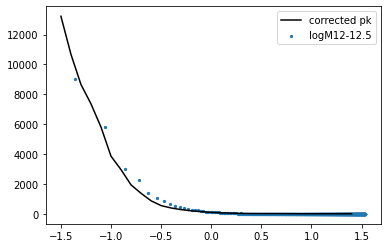

In [145]:

logks = np.arange(-1.5,1.5, 0.1)
plt.scatter(np.log10(Pk12["k"]),Pk12["power"].real-Pk12.attrs["shotnoise"], s=5, label="logM12-12.5")
plt.plot(logks, fit_pow(logks, *pop_fit12), label="corrected pk", c="k")

#plt.ylim(-100,100)
plt.legend()